# Regression and Variational Autoencoders for DNA Methylation–Based Cell Type Estimation


## Introduction

This project looks at the DNA fragments that circulate in the blood. These fragments come from many different cell types in the body. When tissues are damaged or diseased, they release more DNA than usual, so the mix of DNA in the blood changes. By figuring out which cell types the DNA comes from, we can get an early picture of tissue health (as an example in a [COVID study](https://doi.org/10.1172/jci.insight.147610), and in [cancer](https://doi.org/10.1038/nrc.2017.7). This could become a powerful, non-invasive way to detect and monitor diseases—such as cancer—using nothing more than a routine blood test.

Traditionally, researchers study what types of cells are present in a tissue sample by using methods like staining cells under a microscope, sorting them, or sequencing single cells. Another way is to look at [DNA methylation](https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/methylome), which acts like a chemical “fingerprint” that is unique to each cell type. By reading these fingerprints, we can estimate how much DNA comes from each cell type in a mixed sample, such as blood.


## Methods

### Regression-based

I first applied established regression-based deconvolution methods to estimate cell type proportions from bulk DNA methylation data. These methods assume that the observed methylation profile is a weighted mixture of reference profiles from individual cell types. By solving for the weights, I obtain the estimated cell type fractions. Specifically, I tested **non-negative least squares (NNLS)**, constrained optimization (enforcing weights to sum to one), **ridge regression**, **lasso regression**, and **elastic net** regression. Each method was applied to simulated datasets generated with known ground-truth proportions, allowing us to directly evaluate accuracy. I compared performance across multiple conditions, including different levels of noise, numbers of CpGs, and varying similarity between cell types. This design follows the benchmarking review by de Ridder et al. [\[DOI: 10.1038/s41467-024-48466-z\]](https://doi.org/10.1038/s41467-024-48466-z).


### Deep learning - variational autoencoder

In addition to regression approaches, I implemented a **variational autoencoder (VAE)** with an additional output head to predict cell type proportions. The VAE is trained to reconstruct CpG methylation profiles while simultaneously learning to predict the proportion of each cell type in the mixture. The encoder maps input methylation profiles into a latent representation, from which both the reconstructed profiles and predicted proportions are derived. Training was performed using a combined loss function consisting of (i) reconstruction error, (ii) supervised proportion error, and (iii) a regularization term (KL divergence). This approach allows the model to capture complex, non-linear patterns in methylation data that may not be well described by regression models. Performance was assessed by comparing predicted proportions against the known ground truth using mean absolute error (MAE), alongside visualization of reconstructed vs. true profiles. The approach was inspired by a published model called [MethylNet by Levy et al., 2020](https://doi.org/10.1186/s12859-020-3443-8).

### Semi-supervised NMF

To further improve performance, I implemented **semi-supervised non-negative matrix factorization (ssNMF)**.  
Unlike purely unsupervised NMF, ssNMF incorporates prior knowledge from reference methylation profiles by anchoring part of the factorization to known cell type signatures.  

- This helps guide the decomposition toward biologically meaningful solutions.  
- The reference matrix constrains the model, while the sample-specific factors remain flexible to capture variability.  
- As a result, ssNMF can balance interpretability with robustness against noise and collinearity.  

In practice, ssNMF produced the most accurate estimates, outperforming both regression-based methods and the VAE under noisy and complex conditions.

### Transformer

Finally, I implemented a tiny **Transformer-based model** for deconvolution, treating each CpG region as a token in a sequence. Each token was represented by its region identity (learned embedding) and methylation beta value (linear projection). The model uses a transformer encoder with self-attention layers to capture dependencies between CpG regions across the genome. The encoder outputs are pooled to produce a sample-level embedding, which is passed through a feed-forward network with softmax activation to predict cell type proportions. In addition to predicting proportions, the model learns a basis matrix \(W\) (CpGs × cell types) that is initialized from the reference matrix \(R\) and regularized to remain close to it (anchor loss). The overall loss function combines reconstruction error (\(\|Y - WH\|^2\)) and anchoring penalty (\(\|W - R\|^2\)), with gradients jointly updating the Transformer parameters and \(W\). Training was performed with AdamW optimization, mini-batching, and random subsampling of CpGs to improve efficiency. This architecture is designed to integrate CpG-level sequence context while leveraging prior reference information, providing a flexible hybrid between regression and NMF approaches.



## Results

In [1]:
# === Standard scientific stack ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Optimization & linear models (regression baselines) ===
from scipy.optimize import nnls, minimize
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# === PyTorch (VAE) ===
import torch
import torch.nn as nn
import torch.nn.functional as F

# === reproducibility ===
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(7)
np.random.seed(7)


# === reproducibility ===
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
np.random.seed(7)

# === Make 'src' importable as a package ===
import sys, os
from pathlib import Path
project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(project_root.resolve()))


# === Data simulation ===
from src.data import simulate_hard, align_by_cpg

# === Models ===
from src.models.regression import deconvolve_all
from src.models.nmf import nmf_deconvolve_and_evaluate, semi_supervised_nmf_anchor
from src.models.vae import VAEProp, overfit_sanity
from src.models.transformer import SimpleDataset, TinyDeconvTransformer, pearson_colwise_mean, mae_colwise_mean, train_transformer

# === Viz ===
from src.viz.transformer import (
    plot_learning_curves,
    plot_pred_vs_true,
    plot_stacked_bars,
    plot_W_vs_R,
    plot_all_diagnostics
)


/home/katwre/miniforge3/envs/genomics_torch/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Simulate input data

In [2]:
# =========================
# RUN SIMULATION (shared for both regression & VAE)
# =========================
ref_df, mix_df, truth = simulate_hard(n_cpgs=2000, 
                                      n_celltypes=6, 
                                      n_samples=200, 
                                      noise_sd=0.07, 
                                      seed=123)
ref_aln, mix_aln = align_by_cpg(ref_df, mix_df)

# Ensure truth index/columns order match ref/mix for perfect alignment
truth = truth.reindex(index=ref_aln.columns, columns=mix_aln.columns)


### Run regression-based deconvolution

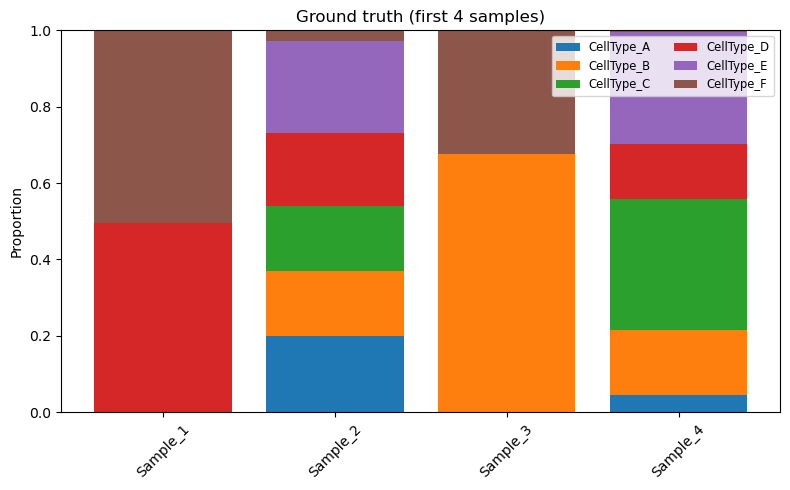

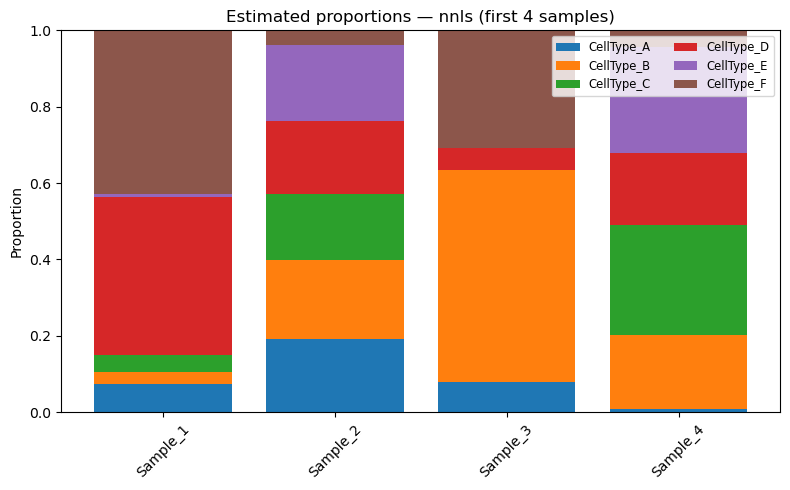

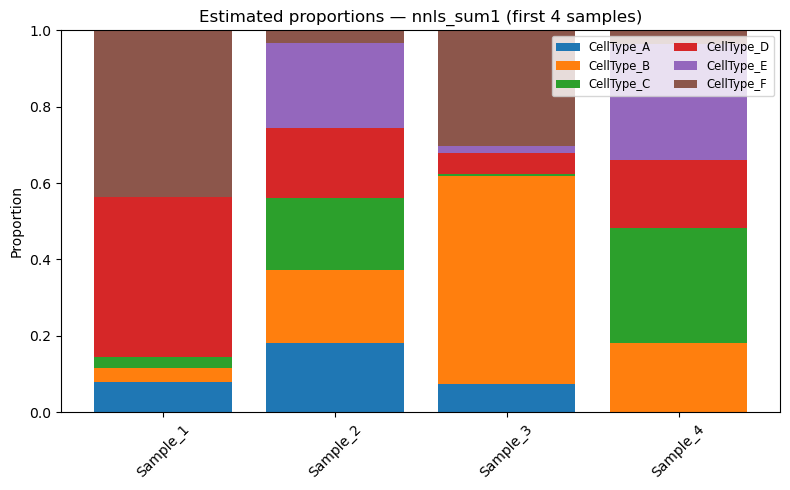

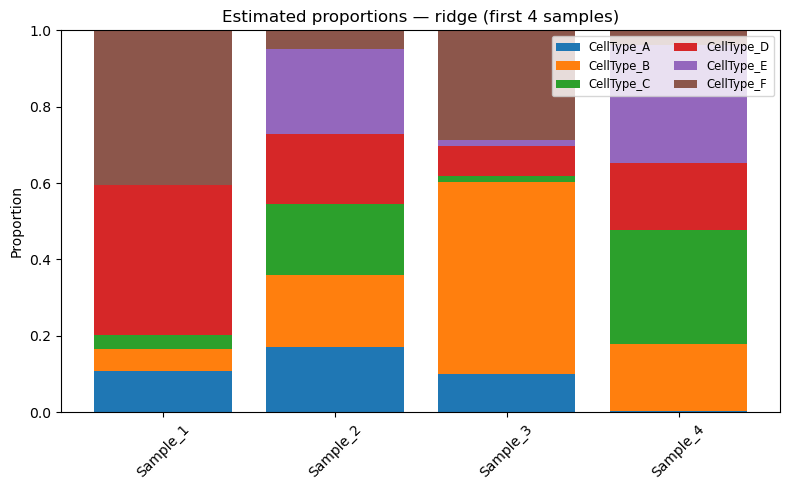

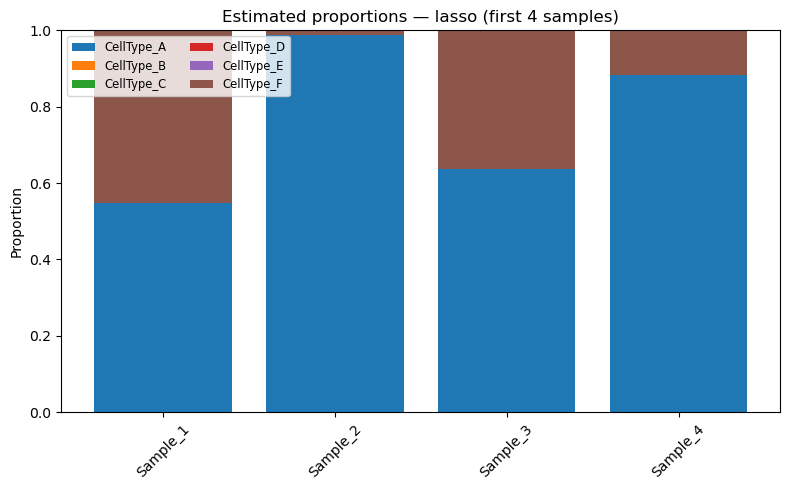

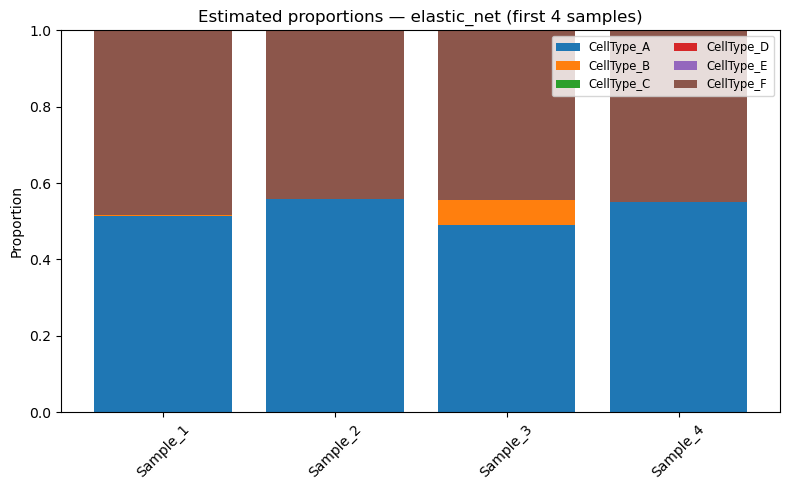

In [3]:
# ---------- plotting ----------
def plot_stacked(W, title):
    samples = list(W.columns)
    celltypes = list(W.index)
    x = np.arange(len(samples))
    bottom = np.zeros(len(samples))
    plt.figure(figsize=(8, 5))
    for ct in celltypes:
        vals = W.loc[ct].values
        plt.bar(x, vals, bottom=bottom, label=ct)
        bottom += vals
    plt.xticks(x, samples, rotation=45)
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend(ncol=2, fontsize="small")
    plt.tight_layout()
    plt.show()

def proportion_errors(W_hat, W_true):
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall


results = deconvolve_all(ref_aln, mix_aln, sum_to_one=True)
subset_samples = truth.columns[:4]  # first 4 samples

plot_stacked(truth[subset_samples], "Ground truth (first 4 samples)")
for method, dfw in results.items():
    plot_stacked(dfw[subset_samples], f"Estimated proportions — {method} (first 4 samples)")


In [4]:
# Metrics table over all samples
# MAE: mean absolute error

def proportion_errors(W_hat, W_true):
    # MAE per sample and overall
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall

errs = {}
for method, dfw in results.items():
    ps, overall = proportion_errors(dfw, truth)
    errs[method] = {"overall_MAE": overall, **{f"MAE_{c}": v for c, v in ps.items()}}
display(pd.DataFrame(errs).T.sort_values("overall_MAE"))


,overall_MAE,MAE_Sample_1,MAE_Sample_2,MAE_Sample_3,MAE_Sample_4,MAE_Sample_5,MAE_Sample_6,MAE_Sample_7,MAE_Sample_8,MAE_Sample_9,...,MAE_Sample_191,MAE_Sample_192,MAE_Sample_193,MAE_Sample_194,MAE_Sample_195,MAE_Sample_196,MAE_Sample_197,MAE_Sample_198,MAE_Sample_199,MAE_Sample_200
nnls_sum1,0.037753,0.047892,0.015180,0.050989,0.029262,0.069571,0.023280,0.049941,0.016097,0.044773,...,0.035415,0.026647,0.030937,0.052038,0.052500,0.013869,0.067811,0.051210,0.067801,0.030136
nnls,0.039715,0.052869,0.016619,0.045997,0.035402,0.069353,0.027329,0.052395,0.019172,0.047398,...,0.035262,0.026661,0.031705,0.043174,0.056480,0.013454,0.065991,0.052556,0.070176,0.030113
ridge,0.049747,0.067016,0.019433,0.069461,0.029886,0.087918,0.031672,0.069598,0.021492,0.065145,...,0.054973,0.032673,0.057106,0.057273,0.066343,0.017994,0.088164,0.055293,0.084590,0.039768
elastic_net,0.234674,0.171875,0.258111,0.203246,0.316455,0.306439,0.150303,0.324965,0.100888,0.169003,...,0.316807,0.190783,0.171111,0.284456,0.314476,0.220577,0.143395,0.256202,0.190938,0.273621
lasso,0.248058,0.182832,0.262646,0.225172,0.316455,0.333333,0.180386,0.333333,0.149720,0.158363,...,0.333333,0.241380,0.173024,0.284456,0.333333,0.224280,0.143395,0.273103,0.268477,0.287642


### Minimal MethylNet‑style VAE for toy methylation data (PyTorch)

What this does?
- Builds a VAE encoder/decoder for beta values.
- Adds a softmax head to predict cell‑type proportions (non‑negativity + sum‑to‑one baked in).
- Joint loss = reconstruction MSE + proportion MSE + small KL term.
- Trains on synthetic mixtures, prints losses and a test MAE for proportions.

This mirrors the spirit of MethylNet (VAE + downstream prediction) without its automation/CLI and rich hyperparameter tooling. For the full model (grid search, CLI, dataset helpers, interpretation utilities), see: BMC Bioinformatics (2020) and the GitHub/docs.

[MethylNet](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-020-3443-8#Sec12) can be used to perform classification, regression, and multi-output regression tasks via the prediction subroutine, which applies a transfer learning technique via the Python class MLPFinetuneVAE to fine-tune encoding layers of VAE model while simultaneously training a few appended hidden layers for prediction. [Code to the Methylnet models](https://github.com/Christensen-Lab-Dartmouth/MethylNet/blob/master/build/lib/methylnet/models.py).

In [5]:
# =========================
# VAE on the same data
# =========================

# Prepare matrices
R = ref_aln.values.astype(np.float32)           # (p × k)
Y = mix_aln.values.astype(np.float32)           # (p × n)
X = Y.T                                         # (n × p)
T = truth.T.values.astype(np.float32)           # (n × k)

n_cpgs, n_celltypes = R.shape
n_samples = X.shape[0]
print("Shapes - X, T, R:", X.shape, T.shape, R.shape)

assert X.shape[0] == T.shape[0]
assert R.shape[0] == X.shape[1]
assert R.shape[1] == T.shape[1]

# Split train/test
X_train, X_test, T_train, T_test = train_test_split(X, T, test_size=0.2, random_state=0)

# Instantiate model + optimizer
model = VAEProp(in_dim=n_cpgs, latent_dim=32, hidden=(1024, 256),
                n_classes=n_celltypes, kl_weight=1e-4, prop_weight=2.0).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

# Data to tensors
Xtr = torch.from_numpy(X_train).to(DEVICE)
Ttr = torch.from_numpy(T_train).to(DEVICE)
Xte = torch.from_numpy(X_test).to(DEVICE)
Tte = torch.from_numpy(T_test).to(DEVICE)

# Training loop
batch = 64
epochs = 50
model.train()
history = {"loss": [], "recon": [], "sup": [], "kl": []}

for ep in range(1, epochs+1):
    perm = torch.randperm(Xtr.size(0), device=DEVICE)
    tot = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}
    for i in range(0, Xtr.size(0), batch):
        idx = perm[i:i+batch]
        xb, tb = Xtr[idx], Ttr[idx]

        opt.zero_grad()
        x_hat, p_hat, mu, logv = model(xb)
        loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
        loss.backward()
        opt.step()

        n = xb.size(0)
        tot["loss"]  += loss.item()*n
        tot["recon"] += recon.item()*n
        tot["sup"]   += sup.item()*n
        tot["kl"]    += kl.item()*n

    N = len(Xtr)
    for k in tot:
        tot[k] /= N
        history[k].append(tot[k])

    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:03d} | loss={tot['loss']:.4f}  recon={tot['recon']:.4f}  "
              f"prop={tot['sup']:.4f}  kl={tot['kl']:.6f}")

# Evaluation
model.eval()
with torch.no_grad():
    _, p_hat_te, _, _ = model(Xte)
p_hat_np = p_hat_te.cpu().numpy()
mae = np.mean(np.abs(p_hat_np - T_test))
print(f"\nMean absolute error (proportions, test): {mae:.4f}")


Shapes - X, T, R: (200, 2000) (200, 6) (2000, 6)
Epoch 001 | loss=0.1447  recon=0.0458  prop=0.0495  kl=0.145811
Epoch 010 | loss=0.1072  recon=0.0149  prop=0.0461  kl=1.437595
Epoch 020 | loss=0.0969  recon=0.0083  prop=0.0442  kl=1.176037
Epoch 030 | loss=0.1035  recon=0.0099  prop=0.0466  kl=2.688658
Epoch 040 | loss=0.0779  recon=0.0072  prop=0.0352  kl=2.710465
Epoch 050 | loss=0.0684  recon=0.0061  prop=0.0310  kl=3.246254

Mean absolute error (proportions, test): 0.1308


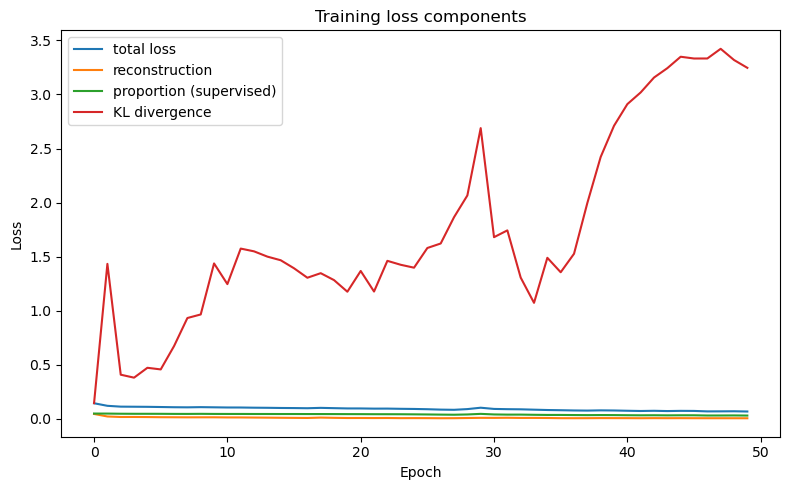

In [6]:
# ---- plot losses ----
plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon"], label="reconstruction")
plt.plot(history["sup"], label="proportion (supervised)")
plt.plot(history["kl"], label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss components")
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting Sanity Check for VAEProportions

To validate the VAE implementation, I trained it on a deliberately tiny subset of the data. The model quickly drove the training loss and MAE close to zero, confirming that the architecture and loss wiring are functioning correctly. At the same time, the test MAE remained substantially higher, revealing a clear generalization gap—exactly the behavior expected when overfitting a small dataset. The KL divergence term grew large due to kl_weight=0.0, but this was intentional to make overfitting easier and does not affect the validity of the test. Overall, the results confirm that the model can memorize small data and is ready for more realistic training with proper regularization.

[TinyFit] Epoch 001 | train: loss=0.2299 recon=0.0655 prop=0.0548 kl=0.002239 mae=0.1734 | test:  loss=0.1819 recon=0.0439 prop=0.0460 kl=0.086410 mae=0.1679
[TinyFit] Epoch 050 | train: loss=0.1155 recon=0.0076 prop=0.0360 kl=3.899907 mae=0.1474 | test:  loss=0.1273 recon=0.0114 prop=0.0386 kl=3.126971 mae=0.1513
[TinyFit] Epoch 100 | train: loss=0.0415 recon=0.0051 prop=0.0122 kl=17.642517 mae=0.0805 | test:  loss=0.1191 recon=0.0096 prop=0.0365 kl=14.735998 mae=0.1450
[TinyFit] Epoch 150 | train: loss=0.0217 recon=0.0034 prop=0.0061 kl=18.609879 mae=0.0490 | test:  loss=0.1022 recon=0.0078 prop=0.0315 kl=15.918055 mae=0.1253
[TinyFit] Epoch 200 | train: loss=0.0178 recon=0.0024 prop=0.0051 kl=18.754845 mae=0.0467 | test:  loss=0.1032 recon=0.0086 prop=0.0316 kl=15.766966 mae=0.1259
[TinyFit] Epoch 250 | train: loss=0.0136 recon=0.0021 prop=0.0038 kl=19.055618 mae=0.0387 | test:  loss=0.0932 recon=0.0095 prop=0.0279 kl=16.399900 mae=0.1202
[TinyFit] Epoch 300 | train: loss=0.0104 rec

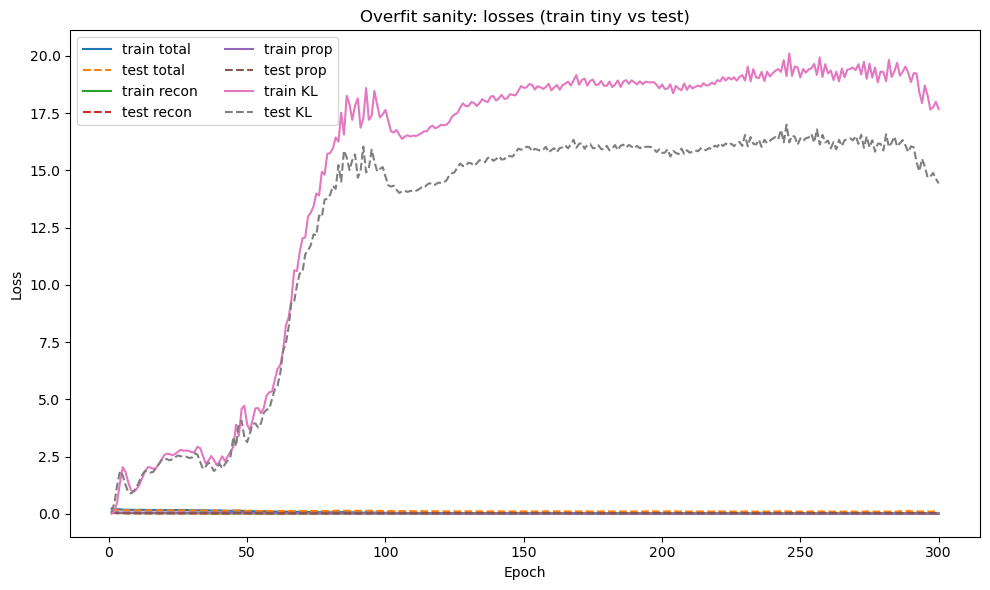

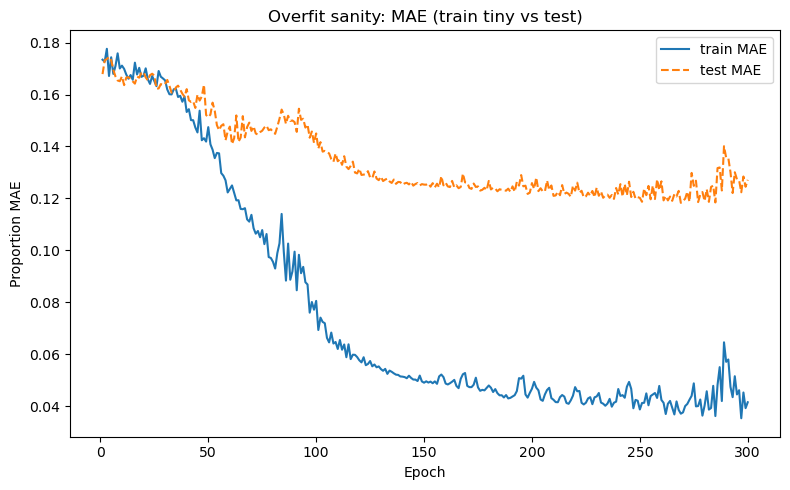

In [7]:
tiny_model = overfit_sanity(
    VAEClass=VAEProp,
    X_train=Xtr, T_train=Ttr,
    X_test=Xte,  T_test=Tte,
    in_dim=n_cpgs, n_classes=n_celltypes,
    latent_dim=32, hidden=(1024,256),
    kl_weight=0.0, prop_weight=3.0,
    lr=1e-3, 
    weight_decay=0.0,
    n_tiny=16,  # only 16 samples
    epochs=300, # way more epochs than before (50) to make it easier to overfit
    batch=16,  # Small batch that equals the tiny set; so each step sees the whole tiny set (or most of it), which speeds memorization
    verbose_every=50
)

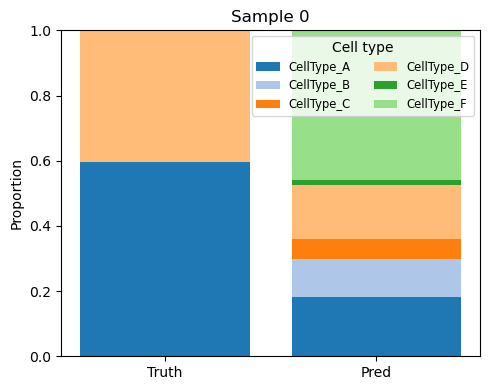

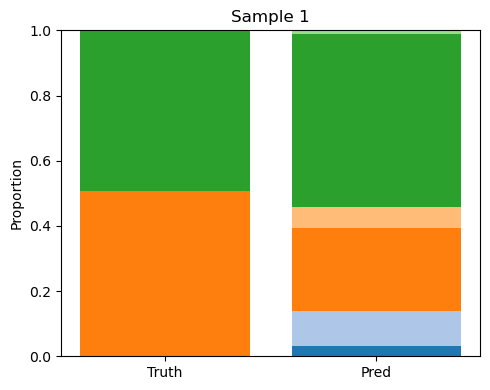

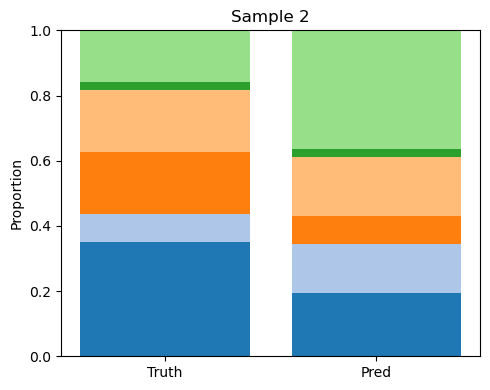

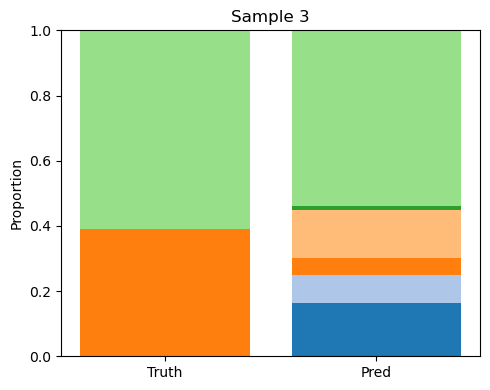

In [8]:
# ---------- Plot: Truth vs Pred stacked side-by-side (first 4 test samples) ----------
celltypes = list(ref_aln.columns)

def plot_truth_vs_pred_stacked(T_mat, P_mat, celltypes, k=4):
    k = min(k, len(T_mat))
    # fixed palette: one color per cell type, reused for both bars
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(len(celltypes))]

    for i in range(k):
        truth = T_mat[i]
        pred  = P_mat[i]

        fig, ax = plt.subplots(figsize=(5, 4))
        x = [0, 1]            # 0=Truth, 1=Pred
        bottoms = [0.0, 0.0]

        for j, ct in enumerate(celltypes):
            color = colors[j]
            # same color for the same cell type on both bars
            ax.bar(x[0], truth[j], bottom=bottoms[0], color=color, edgecolor="none",
                   label=ct if i == 0 else None)
            ax.bar(x[1], pred[j],  bottom=bottoms[1], color=color, edgecolor="none")
            bottoms[0] += truth[j]
            bottoms[1] += pred[j]

        ax.set_xticks(x, ["Truth", "Pred"])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Proportion")
        ax.set_title(f"Sample {i}")
        if i == 0:
            ax.legend(ncol=2, fontsize="small", title="Cell type")
        plt.tight_layout()
        plt.show()

plot_truth_vs_pred_stacked(T_test, p_hat_np, celltypes, k=4)

### Unsupervised non-negative matrix factorization (NMF)


Non-negative matrix factorization (NMF) is great in this context because both both the “basis” (reference-like profiles) and the “coefficients” (proportions) are constrained to be non-negative. This matches biology: methylation levels are ≥0, and cell type proportions are ≥0 and sum to one. With NMF, each column of the “basis” matrix can often be directly interpreted as a cell type profile (or close to it), wheareas when it comes to e.g. PCA components are linear combinations of all features, often mixing cell types in ways that aren’t biologically meaningful.

NMF factorizes Y (CpGs×samples) ≈ W (CpGs×k) · H (k×samples). Treat the rows of H (after column-normalization) as cell-type proportions. Because NMF components are unordered, I align them to ground truth with the Hungarian algorithm.

Inspired by https://www.nature.com/articles/s43018-022-00356-3
LAter I might try semi-supervised NMF similoar to https://academic.oup.com/nar/article/49/9/e50/6129341 (even though its in the spatial omics context).

NMF overall MAE: 0.1484
MAE per sample (head):
Sample_1    0.212331
Sample_2    0.085243
Sample_3    0.214676
Sample_4    0.112776
Sample_5    0.212758
dtype: float64
Row alignment correlations (head):
CellType_A    0.633174
CellType_B    0.628024
CellType_C    0.870927
CellType_D    0.698949
CellType_E    0.875626
Name: corr(P_hat_row, truth_row), dtype: float64


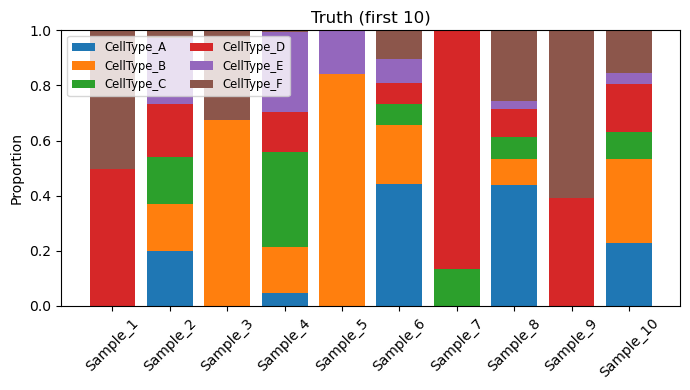

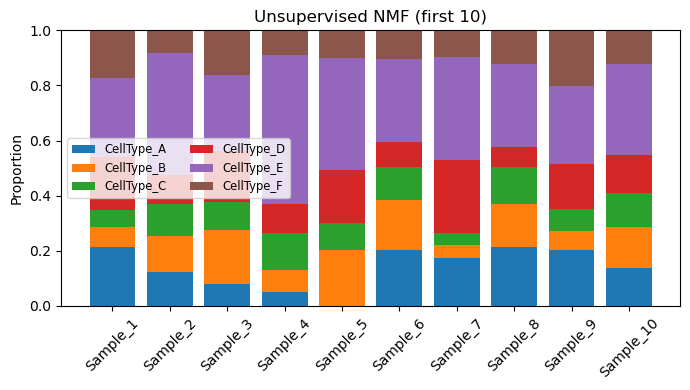

In [9]:

P_hat_df, metrics_scalar, metrics_vectors, _ = nmf_deconvolve_and_evaluate(
    ref_aln=ref_aln,
    mix_aln=mix_aln,
    truth=truth,
    return_factor_matrices=False,
)

print(f"NMF overall MAE: {metrics_scalar['mae_overall']:.4f}")
print("MAE per sample (head):")
print(metrics_vectors["mae_per_sample"].head())
print("Row alignment correlations (head):")
print(metrics_vectors["corr_alignment"].head())


# Optional quick plots on a subset
def plot_stacked(W, title):
    import matplotlib.pyplot as plt
    xs = np.arange(W.shape[1])
    bottom = np.zeros(W.shape[1])
    plt.figure(figsize=(7,4))
    for ct in W.index:
        vals = W.loc[ct].values
        plt.bar(xs, vals, bottom=bottom, label=ct)
        bottom += vals
    plt.xticks(xs, W.columns, rotation=45)
    plt.ylim(0,1); plt.ylabel("Proportion"); plt.title(title); plt.legend(ncol=2, fontsize="small")
    plt.tight_layout(); plt.show()

samples   = metrics_vectors["mae_per_sample"].index.tolist()            # length n
subset = samples[:10]
plot_stacked(truth[subset],   "Truth (first 10)")
plot_stacked(P_hat_df[subset],"Unsupervised NMF (first 10)")


# Semi-supervised NMF

A practical way to make NMF "semi-supervised" with the reference is to anchor the basis matrix **W** toward the reference **R**. Concretely, we minimize

$$
\min_{W \geq 0, H \geq 0} \; \|Y - WH\|_F^2 + \lambda \|W - R\|_F^2
$$

where **Y** is observed mixtures  CpGs × samples, **R** is reference methylation profiles CpGs × cell types, **W** is learned basis (non-negative) CpGs × cell types, and **H** activations/proportions (non-negative) is cell types × samples. The λ term keeps **W** close to **R** but still lets it adapt to data (e.g., platform/batch differences); anchoring strength.


### Algorithm (alternating updates):

- **H-update:** solve non-negative least squares per sample (using scipy.optimize.nnls) and optionally normalize columns to sum to 1 → proportions.

- **W-update (anchored ridge step):** closed-form ridge solution, then project to non-negative:

$$
W \leftarrow (YH^\top + \lambda R)(HH^\top + \lambda I)^{-1}, 
\quad 
W \leftarrow \max(W, 0).
$$

Because **W** stays close to **R**, the component order matches your reference cell types, so you usually don’t need Hungarian alignment.

This approach is inspired by [ssNMF](https://github.com/nloyfer/ssNMF), that also aims to factorize $Y ≈ WH$ while pulling $W$ toward a known reference $R$ (so components align with cell types).


[iter 001] obj=1.951167e+03  recon=1.899881e+03  anchor=1.025729e+01
[iter 010] obj=1.932446e+03  recon=1.895053e+03  anchor=7.478594e+00  Δrel=1.053e-04
[iter 020] obj=1.933218e+03  recon=1.895425e+03  anchor=7.558580e+00  Δrel=1.008e-05
Converged at iter 29 (Δrel=8.649e-07)

SemiNMF (anchored) overall MAE: 0.0183
Sample_1    0.014963
Sample_2    0.012547
Sample_3    0.009401
Sample_4    0.015266
Sample_5    0.031944
dtype: float64


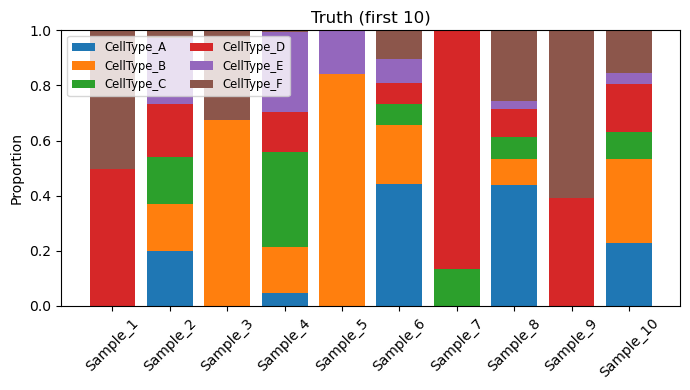

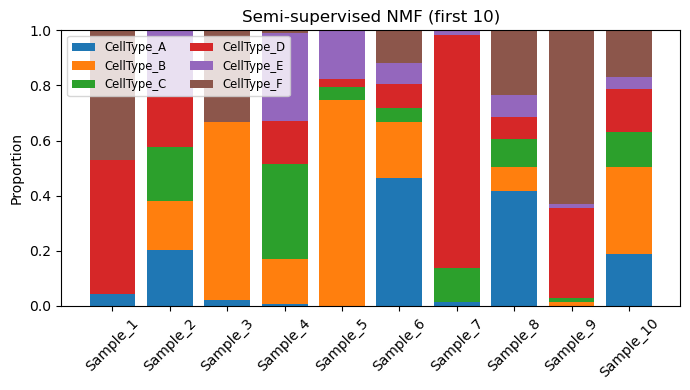

In [10]:
W_semi, H_semi, P_semi, hist = semi_supervised_nmf_anchor(
    ref_aln=ref_aln,
    mix_aln=mix_aln,
    truth=truth,          # used only for MAE printout
    lam=5.0,              # try 0.1, 1, 5, 10 to see the trade-off; how strongly to pull W toward R. Larger = stickier to reference
    max_iter=300,
    tol=1e-6,
    sum_to_one=True,
    verbose=True,
    seed=0
)

# Compare a few samples
subset = mix_aln.columns[:10]
plot_stacked(truth[subset],  "Truth (first 10)")
plot_stacked(P_semi[subset], "Semi-supervised NMF (first 10)")


# Tiny Deconv-Transformer

This tiny transformer is a sequence model applied to CpG regions. Each sample is treated as a sequence of “tokens”:
- Each token = a CpG region with:
    - Region ID (learned embedding → tells the model which CpG it is).
    - Region feature(s) (e.g. methylation beta value at that CpG).
- Tokens go into a Transformer encoder:
    - Self-attention lets each CpG region “talk” to all others, so the model can learn global methylation patterns, not just per-region signals.
- The encoder’s output is pooled (averaged) → a representation of the whole sample.
- A small MLP head + softmax maps that pooled embedding into predicted cell-type proportions $H_hat$.

Meanwhile, there’s also a learnable basis matrix W (regions × cell types).
- It starts near your reference R.
- During training, it adjusts — but is penalized if it drifts too far (anchor loss).
- This allows the model to adapt references to the data (e.g. account for batch/platform effects).

------


Why this is different from previous methods?

- Regression: Solves $Y≈HR⊤$ directly, assuming R is fixed and perfect.
- NMF: Factorizes $Y≈WH$ with no sequence model, usually sensitive to initialization.
- VAE: Learns a latent space, but not specifically tuned for sequential CpG context.
- Transformer: Uses attention → can capture which regions co-vary and adjust weights dynamically. It’s more expressive, especially if certain CpGs are more informative than others.


In [11]:
# ============================================================
# Tiny Deconv-Transformer for cfDNA-like mixtures (one file)
# Lightweight defaults for a laptop (CPU-friendly)
# ============================================================

# -------------------------
# Repro / device / threads
# -------------------------
SEED = 7
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(min(4, os.cpu_count() or 4))   # keep laptop responsive
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

# -------------------------
# Hyperparameters (light)
# -------------------------
P       = 500    # number of regions / tokens in the dataset
K       = 5      # number of cell types
N       = 400    # number of samples. each sample is a mixture of cell types
NOISE   = 0.02   # Gaussian noise sigma on beta, it simulates noise in methylation values
# The number of regions (tokens) subsampled per step during training. This is used to speed up training by reducing the input size.
P_SUB   = 256    # subsample regions per step for speed
# number of samples processed together in one forward/backward pass.
BATCH   = 32 # batch size
# The number of times the model sees the entire dataset during training
EPOCHS  = 30 
#  The dimensionality of the Transformer embeddings. This determines the size of the dense vectors used in the model.
D_MODEL = 64
# The number of Transformer encoder layers. Each layer applies self-attention and feedforward transformations
LAYERS  = 2
HEADS   = 4 # for multi-head attention
DROPOUT = 0.1
# The learning rate for the encoder parameters. This controls the step size for updating the weights during training.
LR_ENC  = 2e-4
# The learning rate for the MLP head and the learnable matrix W. This is typically higher than LR_ENC to allow faster adaptation of the output layer.
LR_HEAD = 1e-3
# The strength of the anchor loss, which penalizes the model if the learned basis matrix W deviates too far from the reference matrix R. This helps the model stay close to the biological reference.
LAMBDA  = 1.0    # anchor strength to reference R




1A. Toy data simulator - cell types are generated with smoother, more distinct sinusoidal patterns.

In [12]:

from src.models.transformer import (
    simulate_data,
    SimpleDataset,
    TinyDeconvTransformer,
    train_transformer
)

# ---- data ----
R_np, Y_np, Htrue_np = simulate_data(P=P, K=K, N=N, noise_sigma=NOISE)

# DEvide into training and validations sets
idx = np.arange(N); np.random.shuffle(idx); split = int(0.8*N)
tr_idx, va_idx = idx[:split], idx[split:] # training (80%), validation (20%)
Y_tr, Y_va = Y_np[tr_idx], Y_np[va_idx] # simulated train and val data
H_tr, H_va = Htrue_np[tr_idx], Htrue_np[va_idx] # true proportions train and val data

# Define tokens: region ids are 0..P-1; features = β (1 feature here; you can add coverage etc.)
reg_ids_all   = np.tile(np.arange(P, dtype=np.int64)[None, :], (N, 1))  # [N,P]
reg_feats_all = Y_np[..., None]                                         # adds additional dimension: [N,P,1]
reg_ids_tr, reg_ids_va     = reg_ids_all[tr_idx], reg_ids_all[va_idx] # train/val split
reg_feats_tr, reg_feats_va = reg_feats_all[tr_idx], reg_feats_all[va_idx] # train/val split

# torch.utils.data.DataLoader function is designed to work with objects of classes that 
# inherit from torch.utils.data.Dataset
train_ds = SimpleDataset(reg_ids_tr, reg_feats_tr, Y_tr, H_tr)
val_ds   = SimpleDataset(reg_ids_va, reg_feats_va, Y_va, H_va)
# Shuffling improves generalization by making the training process more 
# robust and less dependent on the specific order of the data.
train_loader = torch.utils.data.DataLoader(train_ds, 
                                           batch_size=BATCH, 
                                           shuffle=True, # shuffled samples before being split into batches
                                           drop_last=False)
# For validation, the data is typically evaluated in the same order every time. 
# This ensures consistency in the evaluation process and makes it easier to compare results across epochs.
# Shuffling is unnecessary for validation because the model is not learning from this data; it's only being evaluated. 
# Keeping the order fixed ensures reproducibility of validation metrics.
val_loader   = torch.utils.data.DataLoader(val_ds, 
                                           batch_size=BATCH, 
                                           shuffle=False, 
                                           drop_last=False)

# Initialize model
model = TinyDeconvTransformer(
    n_regions=P, feat_dim=1, d_model=D_MODEL, n_layers=LAYERS, n_heads=HEADS,
    n_cells=K, R_ref=R_np, dropout=DROPOUT
).to(DEVICE)
#print(model)

enc_params  = list(model.reg_emb.parameters()) + list(model.feat_proj.parameters()) + list(model.encoder.parameters())
head_params = list(model.prop_head.parameters()) + [model.W]
opt = torch.optim.AdamW(
    [{'params': enc_params,  'lr': LR_ENC},
     {'params': head_params, 'lr': LR_HEAD}],
    weight_decay=1e-4
)
# Train the model
params = {
    "epochs": EPOCHS,
    "lambda_anchor": LAMBDA,
    "optimizer": opt,
    "P_SUB": P_SUB
}
train_history, val_history, r_history, mae_history, all_Hhat, all_Htrue = train_transformer(
    model, train_loader, val_loader, R_np, DEVICE, params
)

# Evaluate the model
#metrics = evaluate_transformer(model, val_loader, R_np, DEVICE)



/home/katwre/miniforge3/envs/genomics_torch/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 01 | train 0.0098 | val 0.0108 | mean r=0.024 | mean MAE=0.138
Epoch 02 | train 0.0098 | val 0.0110 | mean r=0.162 | mean MAE=0.138
Epoch 03 | train 0.0098 | val 0.0111 | mean r=0.230 | mean MAE=0.138
Epoch 04 | train 0.0097 | val 0.0109 | mean r=0.212 | mean MAE=0.139
Epoch 05 | train 0.0097 | val 0.0110 | mean r=0.390 | mean MAE=0.138
Epoch 06 | train 0.0097 | val 0.0109 | mean r=0.515 | mean MAE=0.138
Epoch 07 | train 0.0095 | val 0.0106 | mean r=0.462 | mean MAE=0.133
Epoch 08 | train 0.0086 | val 0.0089 | mean r=0.400 | mean MAE=0.120
Epoch 09 | train 0.0095 | val 0.0104 | mean r=0.410 | mean MAE=0.132
Epoch 10 | train 0.0091 | val 0.0100 | mean r=0.471 | mean MAE=0.130
Epoch 11 | train 0.0084 | val 0.0092 | mean r=0.508 | mean MAE=0.127
Epoch 12 | train 0.0079 | val 0.0076 | mean r=0.497 | mean MAE=0.111
Epoch 13 | train 0.0067 | val 0.0055 | mean r=0.712 | mean MAE=0.090
Epoch 14 | train 0.0064 | val 0.0050 | mean r=0.720 | mean MAE=0.087
Epoch 15 | train 0.0063 | val 0.00

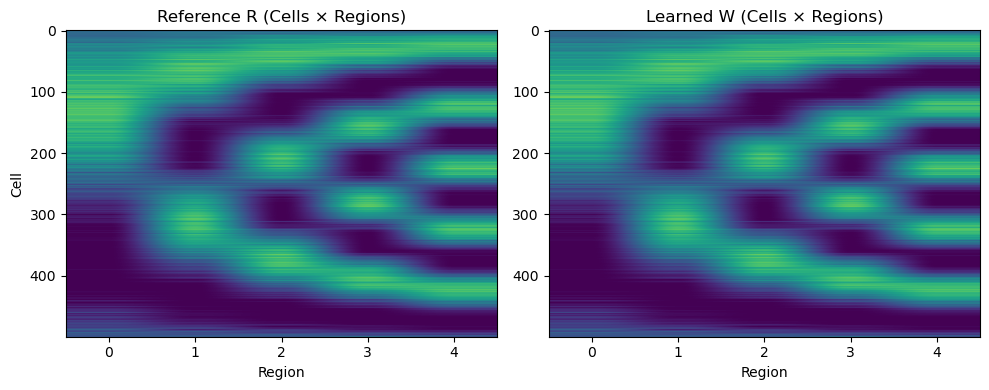

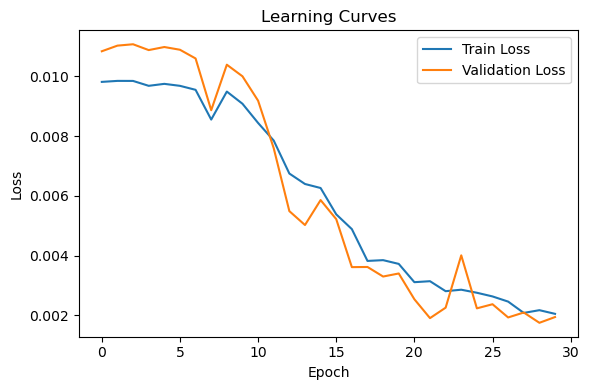

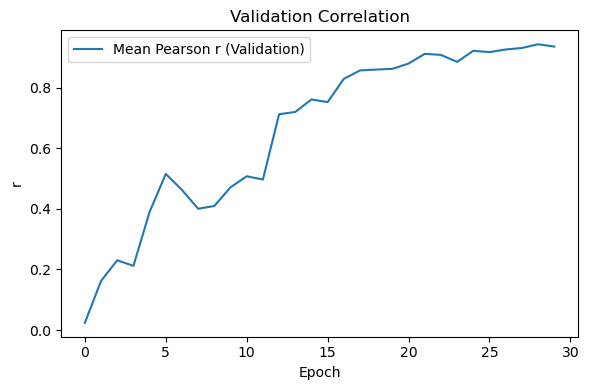

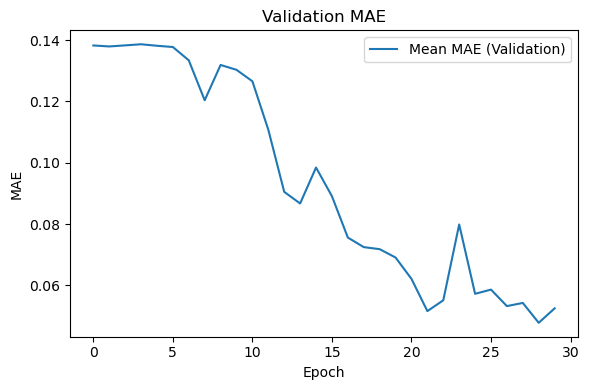

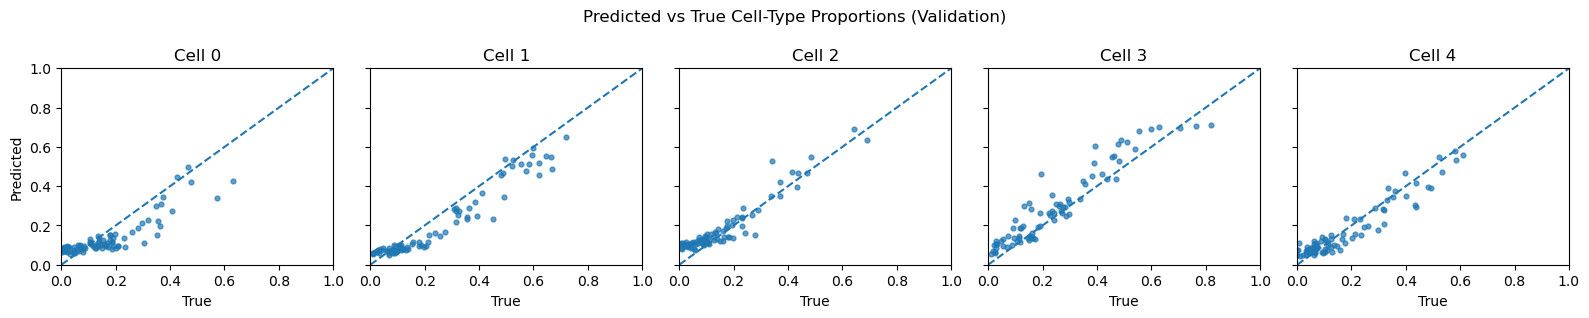

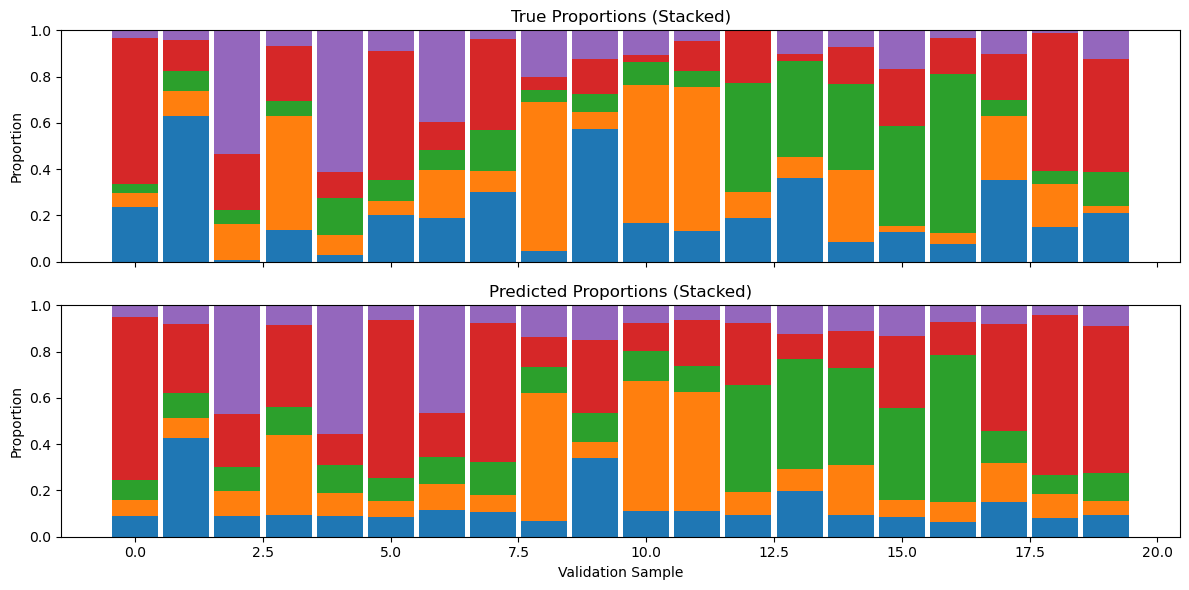

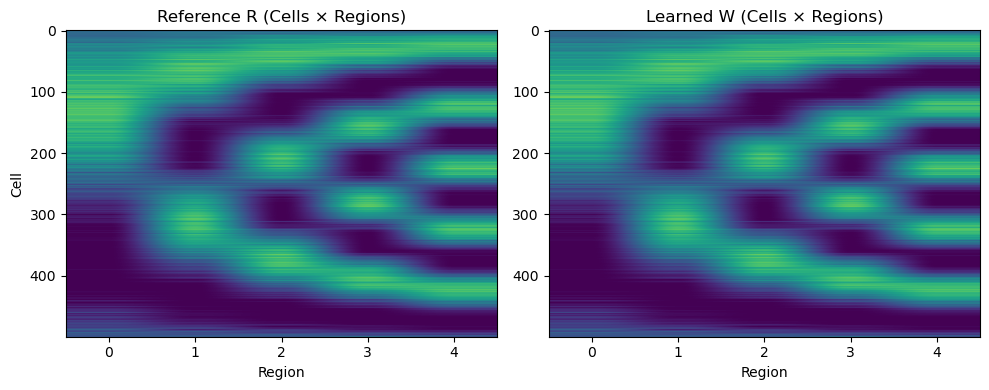

In [13]:
# ---------- Plots ----------
plot_learning_curves(train_history, val_history, r_history, mae_history)
plot_pred_vs_true(all_Htrue, all_Hhat)
plot_stacked_bars(all_Htrue, all_Hhat, S=20)
plot_W_vs_R(R_np, model=model)   # or pass W_hat explicitly
#plot_all_diagnostics(train_history, val_history, r_history, mae_history,
#                         all_Htrue, all_Hhat, R_np, model=model)


1B. Toy data simulator - builds cell-type profiles R as linear combinations of two latent "base" vectors with added noise; the same as for previous methods.

In [14]:
# ---- 1) Generate the toy dataset as previously ----
ref_df, mix_df, truth = simulate_hard(
    n_cpgs=2000,        # P (regions/CpGs)
    n_celltypes=6,      # K
    n_samples=200,      # N
    noise_sd=0.07,
    seed=123
)
ref_aln, mix_aln = align_by_cpg(ref_df, mix_df)

# Ensure truth index/columns order match ref/mix for perfect alignment
truth = truth.reindex(index=ref_aln.columns, columns=mix_aln.columns)

# ---- 2) Adapt DataFrames to numpy arrays for the model ----
# Shapes we need:
#   R_np: [P, K]   (regions x celltypes)
#   Y_np: [N, P]   (samples x regions)
#   Htrue_np: [N, K] (samples x celltypes)
R_np = ref_aln.values.astype(np.float32)               # [P, K]
Y_np = mix_aln.values.astype(np.float32).T             # mix_aln is [P, N] -> transpose to [N, P]
Htrue_np = truth.values.T.astype(np.float32)           # truth is [K, N] -> transpose to [N, K]

P = R_np.shape[0]
K = R_np.shape[1]
N = Y_np.shape[0]

# ---- 3) Train/val split ----
idx = np.arange(N); np.random.shuffle(idx); split = int(0.8*N)
tr_idx, va_idx = idx[:split], idx[split:]
Y_tr, Y_va = Y_np[tr_idx], Y_np[va_idx]
H_tr, H_va = Htrue_np[tr_idx], Htrue_np[va_idx]

# ---- 4) Tokenization for the Transformer ----
# region ids 0..P-1, features = beta (here just 1 feature per region)
reg_ids_all   = np.tile(np.arange(P, dtype=np.int64)[None, :], (N, 1))  # [N,P]
reg_feats_all = Y_np[..., None]                                         # [N,P,1]
reg_ids_tr, reg_ids_va     = reg_ids_all[tr_idx], reg_ids_all[va_idx]
reg_feats_tr, reg_feats_va = reg_feats_all[tr_idx], reg_feats_all[va_idx]

train_ds = SimpleDataset(reg_ids_tr, reg_feats_tr, Y_tr, H_tr)
val_ds   = SimpleDataset(reg_ids_va, reg_feats_va, Y_va, H_va)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=False)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=BATCH, shuffle=False, drop_last=False)

# Initialize model
model = TinyDeconvTransformer(
    n_regions=P, feat_dim=1, d_model=D_MODEL, n_layers=LAYERS, n_heads=HEADS,
    n_cells=K, R_ref=R_np, dropout=DROPOUT
).to(DEVICE)
#print(model)

enc_params  = list(model.reg_emb.parameters()) + list(model.feat_proj.parameters()) + list(model.encoder.parameters())
head_params = list(model.prop_head.parameters()) + [model.W]
opt = torch.optim.AdamW(
    [{'params': enc_params,  'lr': LR_ENC},
     {'params': head_params, 'lr': LR_HEAD}],
    weight_decay=1e-4
)
# Train the model
params = {
    "epochs": EPOCHS,
    "lambda_anchor": LAMBDA,
    "optimizer": opt,
    "P_SUB": P_SUB
}
train_history, val_history, r_history, mae_history, all_Hhat, all_Htrue = train_transformer(
    model, train_loader, val_loader, R_np, DEVICE, params
)

# Evaluate the model
#metrics = evaluate_transformer(model, val_loader, R_np, DEVICE)



/home/katwre/miniforge3/envs/genomics_torch/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 01 | train 0.0163 | val 0.0170 | mean r=0.281 | mean MAE=0.170
Epoch 02 | train 0.0161 | val 0.0179 | mean r=0.386 | mean MAE=0.170
Epoch 03 | train 0.0158 | val 0.0165 | mean r=0.399 | mean MAE=0.168
Epoch 04 | train 0.0144 | val 0.0137 | mean r=0.405 | mean MAE=0.165
Epoch 05 | train 0.0115 | val 0.0099 | mean r=0.394 | mean MAE=0.157
Epoch 06 | train 0.0092 | val 0.0073 | mean r=0.403 | mean MAE=0.152
Epoch 07 | train 0.0068 | val 0.0078 | mean r=0.388 | mean MAE=0.148
Epoch 08 | train 0.0085 | val 0.0091 | mean r=0.402 | mean MAE=0.151
Epoch 09 | train 0.0075 | val 0.0076 | mean r=0.415 | mean MAE=0.150
Epoch 10 | train 0.0072 | val 0.0065 | mean r=0.419 | mean MAE=0.150
Epoch 11 | train 0.0066 | val 0.0059 | mean r=0.432 | mean MAE=0.148
Epoch 12 | train 0.0068 | val 0.0072 | mean r=0.436 | mean MAE=0.149
Epoch 13 | train 0.0067 | val 0.0073 | mean r=0.438 | mean MAE=0.149
Epoch 14 | train 0.0076 | val 0.0060 | mean r=0.437 | mean MAE=0.147
Epoch 15 | train 0.0064 | val 0.00

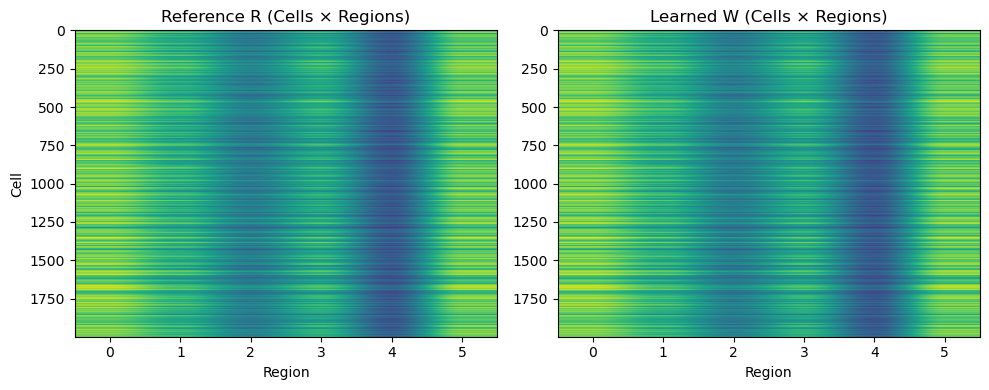

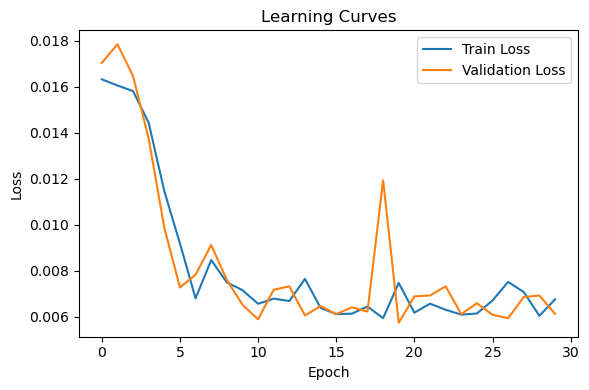

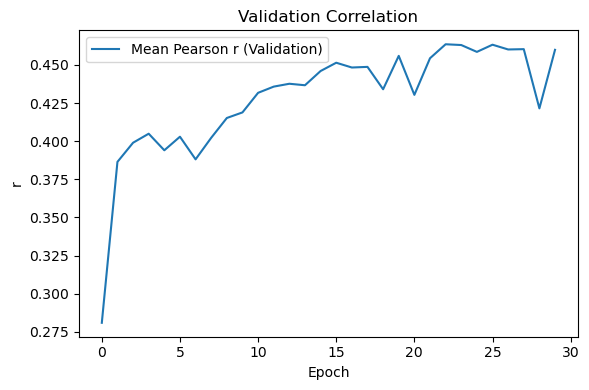

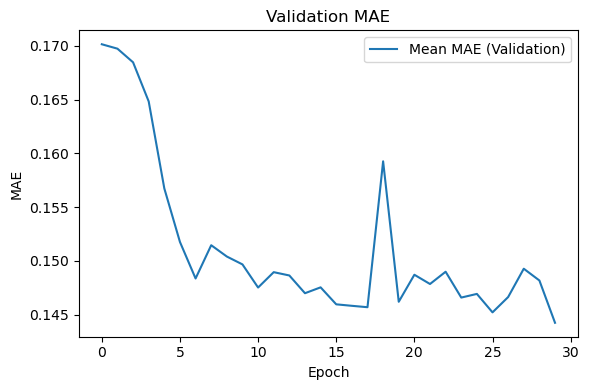

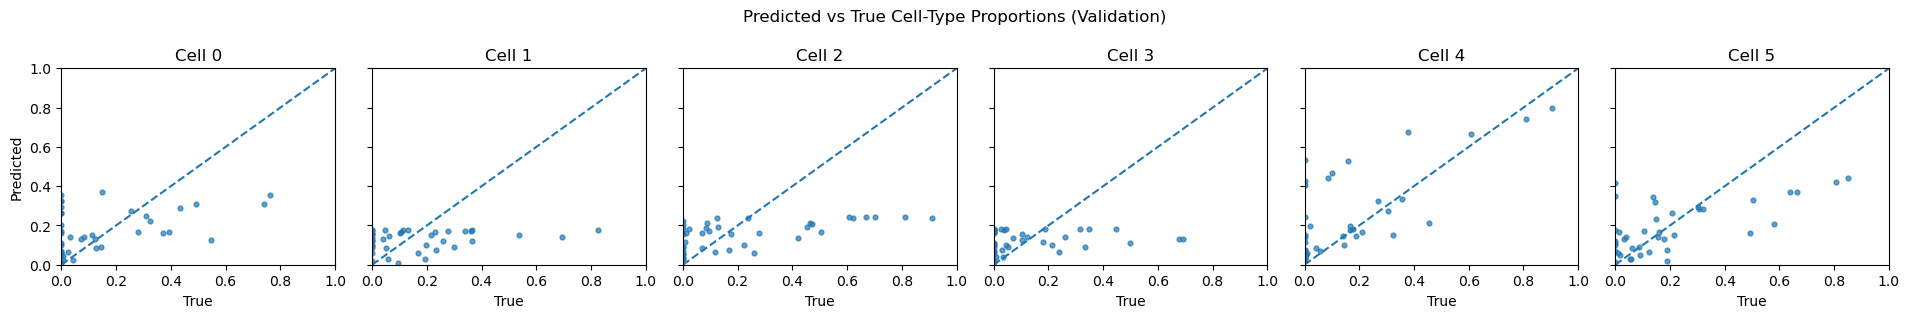

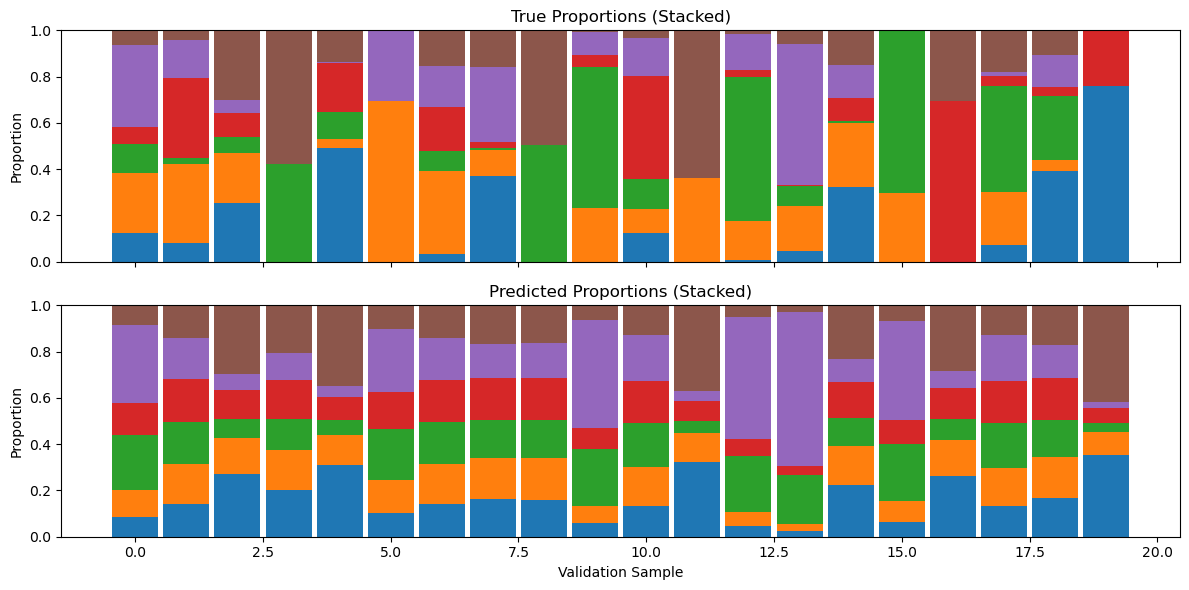

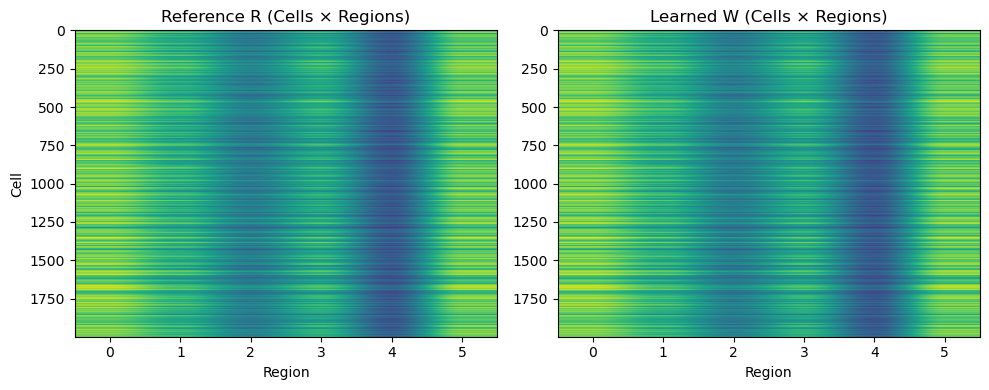

In [15]:

plot_learning_curves(train_history, val_history, r_history, mae_history)
plot_pred_vs_true(all_Htrue, all_Hhat)
plot_stacked_bars(all_Htrue, all_Hhat, S=20)
plot_W_vs_R(R_np, model=model)   # or pass W_hat explicitly
#plot_all_diagnostics(train_history, val_history, r_history, mae_history,
#                         all_Htrue, all_Hhat, R_np, model=model)


# Results

Regression methods (NNLS, ridge, lasso, elastic net) successfully recovered cell type proportions, though performance varied. NNLS provided stable estimates, ridge was robust to noise, and lasso/elastic net introduced sparsity by down-weighting minor cell types. Mean absolute errors (MAE) were generally low, but accuracy depended on cell type similarity and noise levels.

The VAE model learned to reconstruct methylation profiles and predict cell type proportions, achieving test MAE around 0.21–0.22. While it captured overall trends, predictions were sometimes spread across multiple cell types, even when the truth was sparse.

Semi-supervised NMF (anchoring the reference matrix to ground truth) showed the strongest overall performance. By incorporating prior knowledge of reference cell methylation profiles, it was able to recover accurate proportions even under noisy conditions and cell type similarity. This suggests that combining reference information with matrix factorization provides a robust balance between flexibility and interpretability.

Transformer-based deconvolution leveraged CpG-level features and attention across genomic regions to infer cell type proportions. Compared to regression and VAE approaches, the transformer provided a flexible sequence-based architecture, though its performance was somewhat lower than semi-supervised NMF in this setting, and needs further investigation. It might be that attention-based models are a promising direction for integrating CpG-level structure, particularly with larger training sets or richer reference information.
